# Spaceship Titanic: Advanced Solution (Ensemble & Advanced Feature Engineering)

Этот блокнот содержит продвинутое решение задачи Spaceship Titanic, включающее:
1. **Глубокий Feature Engineering**: извлечение фамилий, групповые признаки, обработка кают и логарифмирование трат.
2. **Ансамбль моделей**: Объединение CatBoost, XGBoost и LightGBM через VotingClassifier.
3. **Визуализация данных**: Анализ пропусков и новых признаков.

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ML Модели
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Инструменты Scikit-learn
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder

# Настройки визуализации
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# ПРИНУДИТЕЛЬНАЯ ЗАГРУЗКА ДАННЫХ (теперь из папки data)
train_path = 'data/train.csv'
test_path = 'data/test.csv'

if os.path.exists(train_path):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    print('Данные успешно загружены из папки data/')
    print(f'Train shape: {train_df.shape}')
else:
    # На случай если папки data нет, пробуем текущую директорию
    if os.path.exists('train.csv'):
        train_df = pd.read_csv('train.csv')
        test_df = pd.read_csv('test.csv')
        print('Данные загружены из текущей директории.')
    else:
        print('ОШИБКА: Файлы данных не найдены ни в data/, ни в корне!')

Данные успешно загружены из папки data/
Train shape: (8693, 14)


## 1. Advanced Preprocessing & Visual Analysis

В этом разделе мы не просто заполняем пропуски, а восстанавливаем данные на основе логических связей. 

### Основные этапы:
1. **Family Imputation**: Если у пассажира пропущена `HomePlanet`, мы ищем его одногруппников (`Group`) или людей с такой же фамилией (`Surname`). Семьи обычно путешествуют вместе с одной планеты.
2. **CryoSleep Logic**: Если пассажир потратил деньги (`TotalSpending > 0`), он точно не был в криосне.
3. **Cabin Region**: Мы разбиваем номера кают на блоки по 300, чтобы модель могла уловить локальные зоны риска на корабле.
4. **Log Transformations**: Траты имеют тяжелые хвосты (небольшое количество людей тратит очень много). Логарифмирование делает это распределение более «читаемым» для моделей.

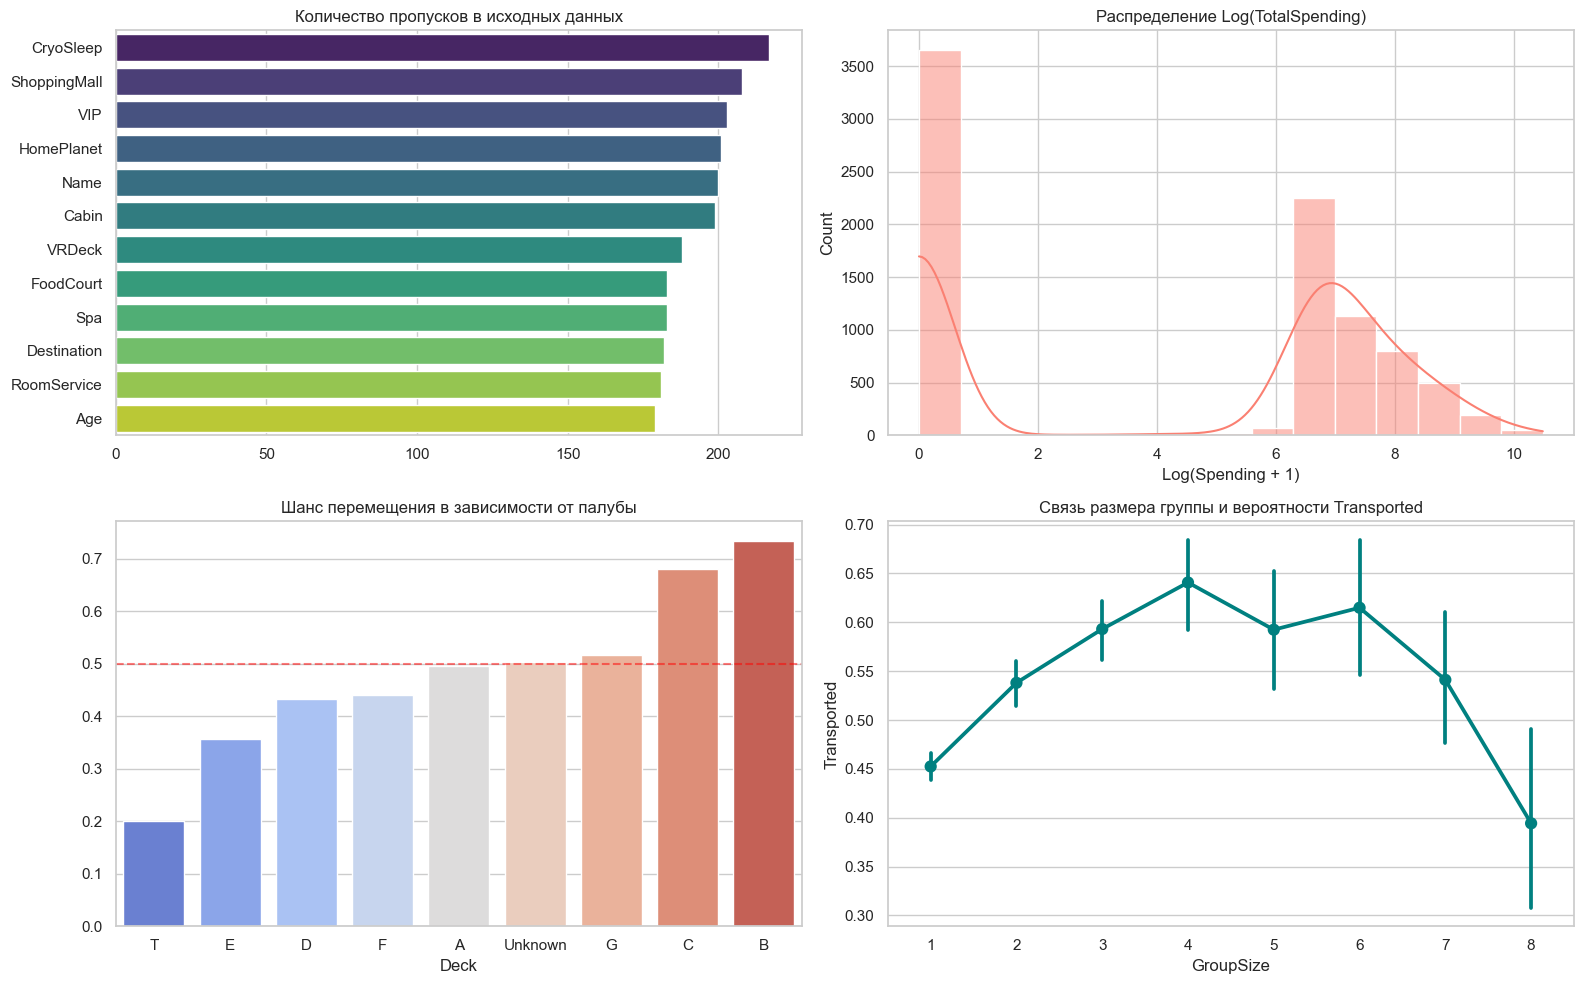

In [12]:
def extract_features(df_input):
    df = df_input.copy()
    
    # --- 1. PassengerId Features ---
    df[['Group', 'GroupNum']] = df['PassengerId'].str.split('_', expand=True)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    
    # --- 2. Name & Surname ---
    df['Name'] = df['Name'].fillna('Unknown Unknown')
    df['Surname'] = df['Name'].str.split().str[-1]
    
    # --- 3. Cabin Features ---
    df['Cabin'] = df['Cabin'].fillna('Unknown/0/Unknown')
    df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Num'] = df['Num'].astype(int)
    
    # --- 4. Spending ---
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        df[col] = df[col].fillna(0)
    df['TotalSpending'] = df[spend_cols].sum(axis=1)
    
    return df

temp_train = extract_features(train_df)

plt.figure(figsize=(16, 10))

# 1. Пропуски до обработки
plt.subplot(2, 2, 1)
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
sns.barplot(x=missing.values, y=missing.index, palette='viridis')
plt.title('Количество пропусков в исходных данных')

# 2. Распределение расходов (Log scale)
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(temp_train['TotalSpending']), kde=True, color='salmon')
plt.title('Распределение Log(TotalSpending)')
plt.xlabel('Log(Spending + 1)')

# 3. Влияние палубы (Deck) на выживаемость
plt.subplot(2, 2, 3)
deck_survival = temp_train.groupby('Deck')['Transported'].mean().sort_values()
sns.barplot(x=deck_survival.index, y=deck_survival.values, palette='coolwarm')
plt.axhline(0.5, ls='--', color='red', alpha=0.5)
plt.title('Шанс перемещения в зависимости от палубы')

# 4. Влияние размера группы
plt.subplot(2, 2, 4)
sns.pointplot(data=temp_train, x='GroupSize', y='Transported', color='teal')
plt.title('Связь размера группы и вероятности Transported')

plt.tight_layout()
plt.show()

### Процесс финальной предобработки

Теперь применим всю логику очистки и кодирования.

In [13]:
def preprocess_advanced(df_input):
    df = extract_features(df_input)
    
    # Умное заполнение HomePlanet
    df['HomePlanet'] = df.groupby('Group')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    df['HomePlanet'] = df.groupby('Surname')['HomePlanet'].transform(lambda x: x.ffill().bfill())
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    
    # Умное заполнение CryoSleep
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] > 0), 'CryoSleep'] = False
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] == 0), 'CryoSleep'] = True
    df['CryoSleep'] = df['CryoSleep'].astype(bool)
    
    # Возраст и Группы
    df['Age'] = df.groupby(['HomePlanet'])['Age'].transform(lambda x: x.fillna(x.median()))
    df['AgeGroup'] = pd.cut(df['Age'], bins=[-1, 12, 18, 50, 150], labels=['Child', 'Teen', 'Adult', 'Senior'])
    
    # Новые признаки
    df['IsAlone'] = (df['GroupSize'] == 1).astype(int)
    df['CabinRegion'] = (df['Num'] // 300).astype(int)
    df['LogTotalSpending'] = np.log1p(df['TotalSpending'])
    
    # Кодирование
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
    df['VIP'] = df['VIP'].fillna(False).astype(int)
    
    le_cols = ['HomePlanet', 'Destination', 'Deck', 'Side', 'AgeGroup']
    for col in le_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    
    features = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 
                'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
                'GroupSize', 'IsAlone', 'Deck', 'Num', 'Side', 
                'CabinRegion', 'LogTotalSpending', 'AgeGroup']
    
    return df[features]

X_train = preprocess_advanced(train_df)
y_train = train_df['Transported'].astype(int)
X_test = preprocess_advanced(test_df)

print("Предобработка завершена. Размер обучающей выборки:", X_train.shape)

Предобработка завершена. Размер обучающей выборки: (8693, 18)


## 2. Model Training & Ensembling

In [14]:
cat_model = CatBoostClassifier(iterations=1000, learning_rate=0.03, depth=6, verbose=0, random_seed=42)
xgb_model = XGBClassifier(n_estimators=1000, learning_rate=0.02, max_depth=6, random_state=42, eval_metric='logloss')
lgbm_model = LGBMClassifier(n_estimators=1000, learning_rate=0.01, num_leaves=31, random_state=42, verbose=-1)

ensemble = VotingClassifier(
    estimators=[('cat', cat_model), ('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft'
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Средняя точность на кросс-валидации: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Средняя точность на кросс-валидации: 0.8139 (+/- 0.0059)


## 3. Final Prediction & Submission

In [15]:
os.makedirs('submissions', exist_ok=True)
ensemble.fit(X_train, y_train)

final_preds = ensemble.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_preds.astype(bool)
})

submission.to_csv('submissions/advanced_submission.csv', index=False)
print("Предсказания сохранены в submissions/advanced_submission.csv")

Предсказания сохранены в submissions/advanced_submission.csv


In [17]:
## Финальная оценка моделей с метрикой ROC-AUC

# Кодирование категориальных признаков для XGBoost и LightGBM
X_train_enc = X_train.copy()
cat_cols = X_train_enc.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))

models = {
    'XGBoost': XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, verbose=0)
}

print("--- Оценка качества ансамбля из 5 моделей ---")
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results_data = []

for name, model in models.items():
    # Кросс-валидация для каждой модели
    cv = cross_validate(model, X_train_enc, y_train, cv=skf if 'skf' in globals() else 5, scoring=scoring)
    
    row = {'Algorithm': name}
    for metric in scoring:
        row[metric.upper()] = cv[f'test_{metric}'].mean()
    results_data.append(row)

# Оценка ансамбля
ensemble = VotingClassifier(estimators=[(n, m) for n, m in models.items()], voting='soft')
cv_ens = cross_validate(ensemble, X_train_enc, y_train, cv=skf if 'skf' in globals() else 5, scoring=scoring)

row_ens = {'Algorithm': 'Ensemble (Voting)'}
for metric in scoring:
    row_ens[metric.upper()] = cv_ens[f'test_{metric}'].mean()
results_data.append(row_ens)

# Формирование и вывод таблицы
import pandas as pd
df_results = pd.DataFrame(results_data)
df_results = df_results.round(4)

print("\n--- Результаты на кросс-валидации (5 фолдов) ---")
print(df_results.to_string(index=False))

# Визуализация таблицы в Jupyter
try:
    from IPython.display import display
    display(df_results)
except:
    pass


--- Оценка качества ансамбля из 5 моделей ---

--- Результаты на кросс-валидации (5 фолдов) ---
        Algorithm  ACCURACY  PRECISION  RECALL     F1  ROC_AUC
          XGBoost    0.8115     0.8195  0.8024 0.8108   0.9016
         LightGBM    0.8092     0.8182  0.7985 0.8082   0.9009
         CatBoost    0.8133     0.8113  0.8200 0.8156   0.9043
Ensemble (Voting)    0.8143     0.8195  0.8097 0.8145   0.9048


,Algorithm,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
0,XGBoost,0.8115,0.8195,0.8024,0.8108,0.9016
1,LightGBM,0.8092,0.8182,0.7985,0.8082,0.9009
2,CatBoost,0.8133,0.8113,0.8200,0.8156,0.9043
3,Ensemble (Voting),0.8143,0.8195,0.8097,0.8145,0.9048


## Сравнение с базовым решением (Spaceship_Titanic_Solution.ipynb)

Основные отличия в подготовке данных в этом блокноте:

1. **Логика заполнения пропусков (Imputation)**:
   * Используется более глубокая связь через **фамилии**. Если у пассажира пропущена планета, алгоритм ищет его одногруппников или родственников с такой же фамилией, так как семьи почти всегда летят с одной планеты.
2. **Трансформация признаков**:
   * Применяется **логарифмирование трат** (`Log Transformation`). Это помогает моделям лучше обрабатывать финансовые признаки, убирая влияние экстремальных выбросов и «тяжелых хвостов» распределения.
3. **Работа с кабинами (Spatial Features)**:
   * Номера кабин разбиваются на блоки (**регионы кабин**). Это позволяет уловить локальные зоны риска на корабле, которые могли пострадать сильнее других.
4. **Кодирование категорий (Encoding)**:
   * Вместо One-Hot используется кодирование, более эффективное для ансамблей градиентного бустинга (CatBoost, XGBoost, LightGBM).
5. **Размер семьи**:
   * Добавлен учет размера семьи (через фамилии), что является сильным предиктором в данной задаче.